# PaySim Dataset Deep Dive & Exploratory Data Analysis (EDA)
This notebook performs step-by-step exploratory data analysis on the synthetic financial transaction dataset to discover signatures of fraud and prepare candidates for machine learning modeling.

## Step 1: Import Required Libraries
We import core analysis libraries (`pandas`, `numpy`) and plotting libraries (`matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

Matplotlib is building the font cache; this may take a moment.


## Step 2: Load Dataset
Load the generated PaySim dataset from the `data/` directory and display the first few rows.

In [2]:
df = pd.read_csv('../data/paysim.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,103,PAYMENT,7715.92,C8050976,342650.21,334934.29,M1280147,0.00,0.00,0,0
1,436,CASH_OUT,38617.68,C2241066,22693.99,0.00,C4771771,2693.16,41310.84,0,0
2,271,TRANSFER,3613.05,C7153709,216851.34,213238.29,C3954331,5540.74,9153.79,0,0
3,107,CASH_IN,4026.08,C4803002,698393.24,702419.32,C9818262,342587.05,338560.97,0,0
4,72,PAYMENT,133798.08,C8421881,15782.89,0.00,M1858746,0.00,0.00,0,0


## Step 3: Understand Dataset Shape
Verify the size of the dataset (number of transactions and features).

In [3]:
df.shape

(100000, 11)

## Step 4: Inspect Data Types and Summary
Identify data types, memory usage, and check for missing values.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            100000 non-null  int64  
 1   type            100000 non-null  str    
 2   amount          100000 non-null  float64
 3   nameOrig        100000 non-null  str    
 4   oldbalanceOrg   100000 non-null  float64
 5   newbalanceOrig  100000 non-null  float64
 6   nameDest        100000 non-null  str    
 7   oldbalanceDest  100000 non-null  float64
 8   newbalanceDest  100000 non-null  float64
 9   isFraud         100000 non-null  int64  
 10  isFlaggedFraud  100000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 8.4 MB


## Step 5: Check Missing Values
Ensure there are no missing values that could crash ML training or streaming logic.

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

## Step 6: Check Duplicate Records
Check for duplicated transaction logs.

In [6]:
duplicates_count = df.duplicated().sum()
print(f'Duplicate rows found: {duplicates_count}')
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)

Duplicate rows found: 0


## Step 7: Analyze the Target Variable (`isFraud`)
Check class distributions and calculate the fraud rate percentage.

In [7]:
print('Transaction Class Counts:')
print(df['isFraud'].value_counts())

fraud_rate = (df['isFraud'].mean()) * 100
print(f'Fraud Rate: {fraud_rate:.4f}%')

Transaction Class Counts:
isFraud
0    99870
1      130
Name: count, dtype: int64
Fraud Rate: 0.1300%


## Step 8: Visualize Fraud Distribution
Plot the counts of fraud vs. non-fraud transactions. A logarithmic scale is used to display the extreme imbalance.

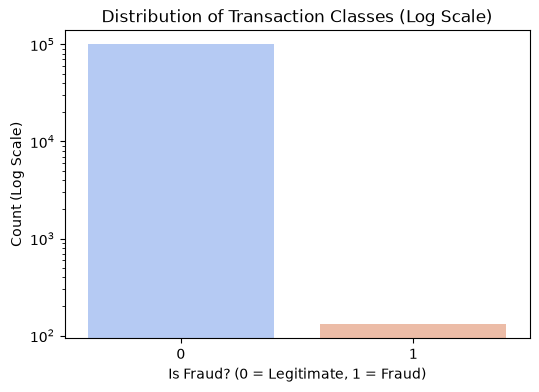

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df, hue='isFraud', palette='coolwarm', legend=False)
plt.yscale('log')
plt.title('Distribution of Transaction Classes (Log Scale)')
plt.xlabel('Is Fraud? (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Count (Log Scale)')
plt.savefig('fraud_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 9: Analyze Transaction Types
Identify the frequencies of transaction types and compute the crosstabulation of transaction type against fraud status.

In [9]:
print('Transaction Type Counts:')
print(df['type'].value_counts())

print('Transaction Type vs Fraud Status Crosstab:')
pd.crosstab(df['type'], df['isFraud'])

Transaction Type Counts:
type
CASH_OUT    34951
PAYMENT     32925
CASH_IN     22192
TRANSFER     8956
DEBIT         976
Name: count, dtype: int64
Transaction Type vs Fraud Status Crosstab:


isFraud,0,1
type,,
CASH_IN,22192,0
CASH_OUT,34844,107
DEBIT,976,0
PAYMENT,32925,0
TRANSFER,8933,23


## Step 10: Analyze Transaction Amounts
Examine the descriptive statistics of transaction amounts and plot their distribution.

Transaction Amount Stats:
count    1.000000e+05
mean     4.092384e+04
std      1.138224e+05
min      1.780000e+01
25%      4.865387e+03
50%      1.338935e+04
75%      3.682633e+04
max      1.252418e+07
Name: amount, dtype: float64


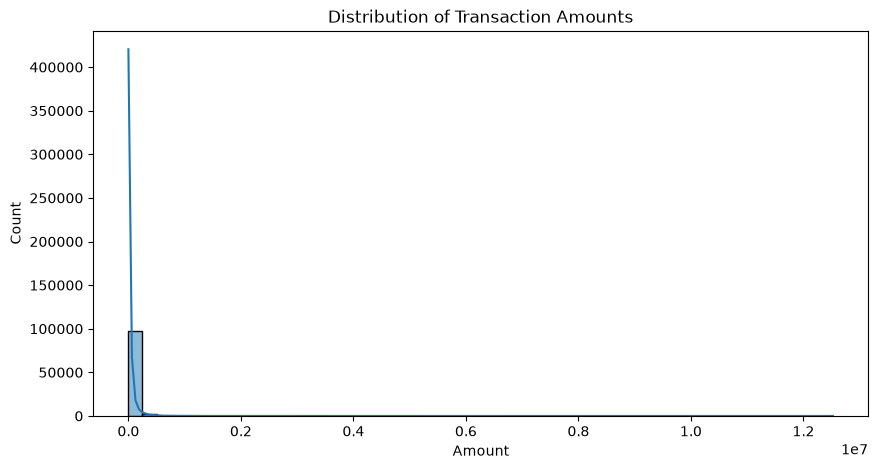

In [10]:
print('Transaction Amount Stats:')
print(df['amount'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.savefig('amount_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 11: Fraud Amount Analysis
Compare the distribution of transaction amounts for fraud vs. legitimate transactions using a boxplot.

/var/folders/q2/p0t1l52x0ml7ssn36qtkw9yr0000gn/T/ipykernel_59222/2371225285.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y='amount', data=df, palette='coolwarm')


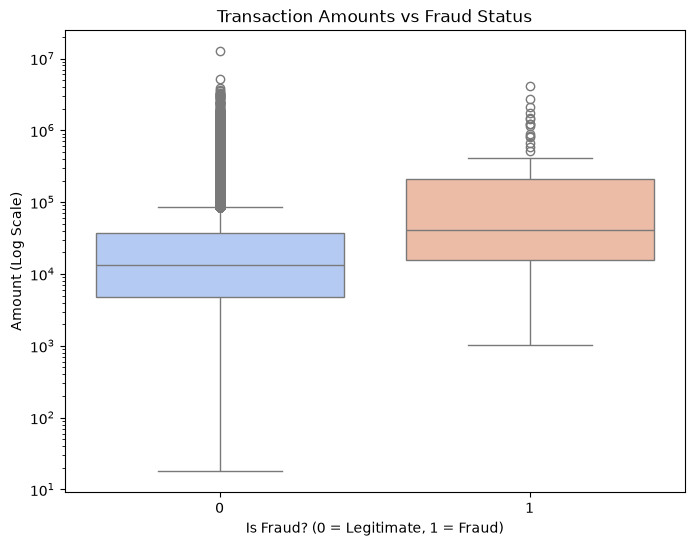

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='isFraud', y='amount', data=df, palette='coolwarm')
plt.yscale('log') # Log scale helps read highly spread financial data
plt.title('Transaction Amounts vs Fraud Status')
plt.xlabel('Is Fraud? (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Amount (Log Scale)')
plt.savefig('amount_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 12: Account Balance Analysis
Inspect balance values (origin and destination, before and after transactions).

In [12]:
df[['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].describe()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05
mean,4.433147e+05,4.348237e+05,3.034304e+05,3.171849e+05
std,3.389527e+06,3.388354e+06,5.511582e+06,5.512091e+06
min,6.860000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.542554e+04,4.093580e+03,0.000000e+00,0.000000e+00
50%,6.006115e+04,5.200038e+04,8.375170e+03,1.466792e+04
75%,2.309637e+05,2.236546e+05,7.364816e+04,1.033916e+05
max,4.846311e+08,4.846284e+08,1.017683e+09,1.017683e+09


## Step 13: Correlation Analysis
Compute the correlation matrix for numeric columns and visualize with a heatmap.

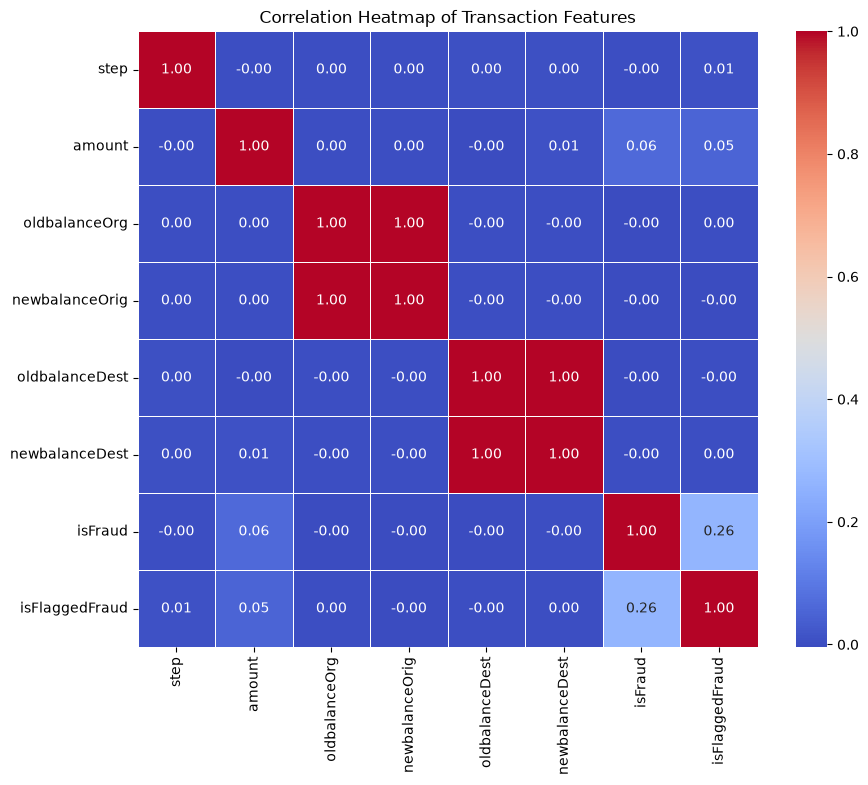

In [13]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Transaction Features')
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()